In [1]:
### Basic
import numpy  as np
import scipy  as sc
import pandas as pd
import glob, os, re
import pickle, sys

### import flowImg
py_path = "/local_data/notebooks/clintko/GitRepo/Proj_Flow2Image"
sys.path.insert(0, py_path)
from flowImg import *

### plotting
import matplotlib.pyplot as plt

### global const
SEED    = 123

/local_data/env-py3/lib/python3.6/site-packages/h5py/__init__.py:36: FutureWarning: Conversion of the second argument of issubdtype from `float` to `np.floating` is deprecated. In future, it will be treated as `np.float64 == np.dtype(float).type`.
  from ._conv import register_converters as _register_converters
Using TensorFlow backend.


In [2]:
%matplotlib inline

In [3]:
def read_npy_from_path(fpath):
    """code snippet for loading numpy array and close the file"""
    fp  = open(fpath, 'rb')
    dat = np.load(fp)
    fp.close()
    return dat


# input the value
dat_dir      = "/data/clintko/flow_EQAPOL_normal"
fpath_costim = os.path.join(dat_dir, "data_costim.npy")
fpath_cmv    = os.path.join(dat_dir, "data_cmv_pp65.npy")
fpath_seb    = os.path.join(dat_dir, "data_seb.npy")

# open and write the file
print("read Costim...")
dat_costim = read_npy_from_path(fpath_costim)

print("read CMV...")
dat_cmv = read_npy_from_path(fpath_cmv)

print("read SEB...")
dat_seb = read_npy_from_path(fpath_seb)

print("Finish!")

read Costim...
read CMV...
read SEB...
Finish!


In [4]:
df1 = dat_costim[1][:, [6, 13]]
df2 = dat_cmv[1][:, [6, 13]]
df3 = dat_seb[1][:, [6, 13]]

print(df1.shape)
print(df2.shape)
print(df3.shape)

(607410, 2)
(515178, 2)
(519426, 2)


In [6]:
matrix = np.array([
    np.array([1] * df1.shape[0]).reshape(-1, 1), 
    np.array([1] * df2.shape[0]).reshape(-1, 1), 
    np.array([1] * df3.shape[0]).reshape(-1, 1)])
label = np.array([0, 1, 2])
coord = np.concatenate([df1, df2, df3])
wrap_data = Data_Wrapper(matrix, label, coord = coord)

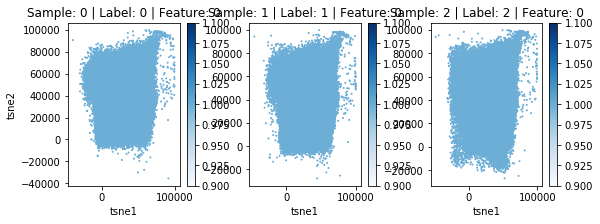

In [7]:
fig, axes = plt.subplots(ncols=3, nrows=1, figsize=(3*3, 3*1))
plt.subplots_adjust(hspace=0.5, wspace=0.3)
axes = axes.ravel()

for idx in range(3):
    ax = axes[idx]
    cax = wrap_data.plot_coord(ax, k=idx, p = 0, s = 1, cmap = "Blues")
    ax.set_xlabel("tsne1"); ax.set_ylabel("tsne2")
    fig.colorbar(cax, ax=ax)
pass

In [8]:
%%time
density = Transform_Density(sig2 = 1)
wrap_img_var01 = density.transform(wrap_data, verbose = True)

Sample: 0


ERROR:numba.cuda.cudadrv.driver:Call to cuDevicePrimaryCtxRetain results in CUDA_ERROR_OUT_OF_MEMORY


CudaAPIError: [2] Call to cuDevicePrimaryCtxRetain results in CUDA_ERROR_OUT_OF_MEMORY